# Symulacja i Analiza Statystyczna Szpitalnego Oddziału Ratunkowego (SOR) z Regresją Wieloraką

Ten program przeprowadza kompleksową analizę działania Szpitalnego Oddziału Ratunkowego (SOR) przy użyciu:
1. **Modelu kolejkowego M/M/c** - symulacja dyskretnych zdarzeń
2. **Analizy statystycznej** - porównanie z teorią kolejek
3. **Regresji wielorakiej** - modelowanie zależności między parametrami a wydajnością

Celem jest zrozumienie dynamiki systemu, oszacowanie kluczowych metryk wydajności oraz budowa modeli regresyjnych do przewidywania wydajności systemu.

### 1. Import niezbędnych bibliotek

Na początek importujemy wszystkie biblioteki potrzebne do symulacji, obliczeń, analizy statystycznej i regresji wielorakiej.

In [657]:
import heapq
import random
import numpy as np
import math
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

### 2. Definicja klasy symulatora

Poniższa komórka zawiera pełną klasę SORSimulator_MMc, która jest sercem naszej symulacji. Implementuje ona logikę symulacji dla systemu M/M/c, gdzie pacjenci są obsługiwani w kolejności przybycia (FIFO).

In [658]:
class SORSimulator_MMc:
    """
    Symulator Szpitalnego Oddziału Ratunkowego (SOR) jako klasyczna kolejka M/M/c.
    Pacjenci są obsługiwani w kolejności przybycia (FIFO).
    Implementuje dyskretną symulację zdarzeniową.
    """
    def __init__(self, lambda_rate, mu_rate, c, max_patients):
        if not (lambda_rate > 0 and mu_rate > 0 and c > 0 and max_patients > 0):
            raise ValueError("Parametry lambda, mu, c oraz max_patients muszą być dodatnie.")
        self.lambda_rate = lambda_rate
        self.mu_rate = mu_rate
        self.c = c
        self.max_patients = max_patients

        self.rho = self.lambda_rate / (self.c * self.mu_rate)
        if self.rho >= 1:
            print(f"UWAGA: System jest niestabilny (rho = {self.rho:.3f} >= 1).")

        # Inicjalizacja stanu
        self.clock = 0.0
        self.event_queue = []
        self.doctor_free_times = [0.0] * self.c
        self.waiting_queue = []
        
        self.patient_data = {}
        self.num_patients_treated = 0
        self.next_patient_id = 0
        
        self.generated_interarrival_times = []
        self.generated_treatment_times = []

    def _generate_exponential_time(self, rate):
        return random.expovariate(rate)

    def _schedule_event(self, time, event_type, data):
        heapq.heappush(self.event_queue, (time, event_type, data))

    def run(self):
        """Główna pętla symulacji."""
        initial_arrival_time = self._generate_exponential_time(self.lambda_rate)
        self.generated_interarrival_times.append(initial_arrival_time)
        self._schedule_event(initial_arrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
        self.next_patient_id += 1

        while self.num_patients_treated < self.max_patients:
            if not self.event_queue:
                print("Błąd: Kolejka zdarzeń pusta przed obsłużeniem wszystkich pacjentów.")
                break
            
            event_time, event_type, data = heapq.heappop(self.event_queue)
            self.clock = event_time
            
            if event_type == "ARRIVAL":
                self._handle_arrival(data['patient_id'])
            elif event_type == "DEPARTURE":
                self._handle_departure(data['patient_id'], data['doctor_id'])

    def _handle_arrival(self, patient_id):
        self.patient_data[patient_id] = {'arrival_time': self.clock}

        if self.next_patient_id < self.max_patients:
            interarrival_time = self._generate_exponential_time(self.lambda_rate)
            self._schedule_event(self.clock + interarrival_time, "ARRIVAL", {'patient_id': self.next_patient_id})
            self.next_patient_id += 1
            self.generated_interarrival_times.append(interarrival_time)
        
        # Sprawdź czy JAKIKOLWIEK lekarz jest dostępny TERAZ
        available_doctors = [i for i, free_time in enumerate(self.doctor_free_times) 
                            if free_time <= self.clock]
        
        if available_doctors:
            # Wybierz pierwszego dostępnego lekarza
            doctor_id = available_doctors[0]
            self._start_treatment(patient_id, doctor_id)
        else:
            # Wszyscy lekarze są zajęci - pacjent czeka
            self.waiting_queue.append(patient_id)

    def _handle_departure(self, patient_id, doctor_id):
        self.patient_data[patient_id]['departure_time'] = self.clock
        self.num_patients_treated += 1
        
        if self.waiting_queue:
            next_patient_id = self.waiting_queue.pop(0)
            self._start_treatment(next_patient_id, doctor_id)

    def _start_treatment(self, patient_id, doctor_id):
        # Leczenie może rozpocząć się najwcześniej gdy lekarz będzie wolny
        actual_start_time = max(self.clock, self.doctor_free_times[doctor_id])
        
        self.patient_data[patient_id]['treatment_start_time'] = actual_start_time

        treatment_time = self._generate_exponential_time(self.mu_rate)
        self.generated_treatment_times.append(treatment_time)
        departure_time = actual_start_time + treatment_time
        self.doctor_free_times[doctor_id] = departure_time
        self._schedule_event(departure_time, "DEPARTURE", {'patient_id': patient_id, 'doctor_id': doctor_id})

    def calculate_performance_metrics(self):
        wait_times = []
        system_times = []
        
        for data in self.patient_data.values():
            if 'departure_time' in data and 'treatment_start_time' in data:
                wait_times.append(data['treatment_start_time'] - data['arrival_time'])
                system_times.append(data['departure_time'] - data['arrival_time'])
        
        if not wait_times:
            return None
        return {
            "mean_wait_time": np.mean(wait_times),
            "mean_system_time": np.mean(system_times),
            "all_wait_times": wait_times
        }

### 3. Funkcje pomocnicze do analizy

Tutaj definiujemy funkcje, które obliczą wartości teoretyczne dla modelu M/M/c oraz przeprowadzą wnioskowanie statystyczne.

In [659]:
def calculate_theoretical_values(lambda_rate, mu_rate, c):
    """Oblicza teoretyczne wartości dla kolejki M/M/c."""
    rho = lambda_rate / (c * mu_rate)
    if rho >= 1:
        return {"Wq": float('inf'), "Lq": float('inf'), "P0": 0, "rho": rho}
    sum_part = sum([(c * rho)**n / math.factorial(n) for n in range(c)])
    last_part = (c * rho)**c / (math.factorial(c) * (1 - rho))
    P0 = 1 / (sum_part + last_part)
    Lq = (P0 * (lambda_rate / mu_rate)**c * rho) / (math.factorial(c) * (1 - rho)**2)
    Wq = Lq / lambda_rate
    W = Wq + (1 / mu_rate)

    print("\n" + "="*50)
    print("      TEORETYCZNE WARTOŚCI dla M/M/c")
    print("="*50)
    print(f"      Rho (obciążenie systemu): {rho:.4f}")
    print(f"      Wq (średni czas oczekiwania w kolejce): {Wq:.4f} godzin ({Wq * 60:.2f} minut)")
    print(f"      Lq (średnia liczba pacjentów w kolejce): {Lq:.4f}")
    print(f"      W (średni czas w systemie): {W:.4f} godzin ({W * 60:.2f} minut)")
    print(f"      P0 (prawdopodobieństwo, że system jest pusty): {P0:.4f}")

    return {"Wq": Wq, "Lq": Lq, "W": W, "P0": P0, "rho": rho}

def statistical_inference(simulator, sim_results, theoretical_values):
    """Przeprowadza i prezentuje wyniki wnioskowania statystycznego."""
    print("\n" + "="*50)
    print("      WNIOSKOWANIE STATYSTYCZNE")
    print("="*50)

    print("\n1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych")
    ks_arrival = stats.kstest(simulator.generated_interarrival_times, 'expon', args=(0, 1/simulator.lambda_rate))
    print(f"\n   a) Test K-S dla czasów między przybyciami (lambda={simulator.lambda_rate}):")
    print(f"      Statystyka D = {ks_arrival.statistic:.4f}, p-wartość = {ks_arrival.pvalue:.4f}")
    if ks_arrival.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    ks_service = stats.kstest(simulator.generated_treatment_times, 'expon', args=(0, 1/simulator.mu_rate))
    print(f"\n   b) Test K-S dla czasów leczenia (mu={simulator.mu_rate}):")
    print(f"      Statystyka D = {ks_service.statistic:.4f}, p-wartość = {ks_service.pvalue:.4f}")
    if ks_service.pvalue > 0.05:
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0.")
    else:
        print("      Wniosek: ODRZUCONO H0.")

    print("\n2. Porównanie wyników symulacji z modelem teoretycznym")
    mean_wait_sim = sim_results['mean_wait_time']
    theoretical_wq = theoretical_values['Wq']
    
    print("\n   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)")
    print(f"      H0: Średnia z symulacji ({mean_wait_sim:.4f}) jest równa wartości teoretycznej ({theoretical_wq:.4f}).")
    ttest_result = stats.ttest_1samp(a=sim_results['all_wait_times'], popmean=theoretical_wq)
    print(f"      Statystyka t = {ttest_result.statistic:.4f}, p-wartość = {ttest_result.pvalue:.4f}")
    if ttest_result.pvalue > 0.05: 
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0. Wyniki zgodne z teorią.")
    else:
        print("      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.")
        
    print("\n   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)")
    confidence_interval = stats.t.interval(0.95, len(sim_results['all_wait_times'])-1, loc=mean_wait_sim, scale=stats.sem(sim_results['all_wait_times']))
    print(f"      Obliczony przedział: ({confidence_interval[0]:.4f}, {confidence_interval[1]:.4f})")
    print(f"      Wartość teoretyczna: {theoretical_wq:.4f}")
    if confidence_interval[0] <= theoretical_wq <= confidence_interval[1]:
        print("      Wniosek: OK. Wartość teoretyczna mieści się w przedziale ufności.")
    else:
        print("      Wniosek: Wartość teoretyczna POZA przedziałem ufności.")


    # alternatywa dla T Studenta
    print("\n   c) Test Mann-Whitney")
    mw_result = stats.mannwhitneyu(
        sim_results['all_wait_times'], 
        theoretical_wq, 
        alternative='two-sided'
    )
    print(f"      Statystyka U = {mw_result.statistic:.4f}, p-wartość = {mw_result.pvalue:.4f}")
    if mw_result.pvalue > 0.05: 
        print("      Wniosek: OK. Brak podstaw do odrzucenia H0. Wyniki zgodne z teorią.")
    else:
        print("      Wniosek: ODRZUCONO H0. Rozkłady różnią się statystycznie istotnie.")

### 5. Parametry wejściowe i uruchomienie podstawowej symulacji

W tej części definiujemy parametry wejściowe, uruchamiamy podstawową symulację i wywołujemy funkcje analityczne.

In [660]:
# --- Parametry wejściowe ---
LAMBDA_RATE = 5.0    # Średnio 5 pacjentów przybywa na godzinę
MU_RATE = 2.0        # Jeden lekarz obsługuje średnio 2 pacjentów na godzinę
C_DOCTORS = 3        # 3 lekarzy na dyżurze
MAX_PATIENTS = 5000  # Liczba pacjentów do zasymulowania

print("\n" + "="*50)
print("      PARAMETRY SYSTEMU SOR")
print("="*50)
print(f"Intensywność przybyć (λ): {LAMBDA_RATE} pacjentów/godz")
print(f"Intensywność obsługi (μ): {MU_RATE} pacjentów/godz/lekarz")
print(f"Liczba lekarzy (c): {C_DOCTORS}")
print(f"Liczba pacjentów do symulacji: {MAX_PATIENTS}")


      PARAMETRY SYSTEMU SOR
Intensywność przybyć (λ): 5.0 pacjentów/godz
Intensywność obsługi (μ): 2.0 pacjentów/godz/lekarz
Liczba lekarzy (c): 3
Liczba pacjentów do symulacji: 5000


In [661]:
# Obliczenie wartości teoretycznych
theoretical_vals = calculate_theoretical_values(LAMBDA_RATE, MU_RATE, C_DOCTORS)

print("\n" + "="*50)
print("      TEORETYCZNE WARTOŚCI dla M/M/c")
print("="*50)
print(f"      Rho (obciążenie systemu): {theoretical_vals['rho']:.4f}")
print(f"      Wq (średni czas oczekiwania w kolejce): {theoretical_vals['Wq']:.4f} godzin ({theoretical_vals['Wq'] * 60:.2f} minut)")
print(f"      Lq (średnia liczba pacjentów w kolejce): {theoretical_vals['Lq']:.4f}")
print(f"      W (średni czas w systemie): {theoretical_vals['W']:.4f} godzin ({theoretical_vals['W'] * 60:.2f} minut)")
print(f"      P0 (prawdopodobieństwo, że system jest pusty): {theoretical_vals['P0']:.4f}")


      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.8333
      Wq (średni czas oczekiwania w kolejce): 0.7022 godzin (42.13 minut)
      Lq (średnia liczba pacjentów w kolejce): 3.5112
      W (średni czas w systemie): 1.2022 godzin (72.13 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.0449

      TEORETYCZNE WARTOŚCI dla M/M/c
      Rho (obciążenie systemu): 0.8333
      Wq (średni czas oczekiwania w kolejce): 0.7022 godzin (42.13 minut)
      Lq (średnia liczba pacjentów w kolejce): 3.5112
      W (średni czas w systemie): 1.2022 godzin (72.13 minut)
      P0 (prawdopodobieństwo, że system jest pusty): 0.0449


In [662]:
# Uruchomienie podstawowej symulacji
print("\n" + "="*50)
print("      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)")
print("="*50)

simulator = SORSimulator_MMc(LAMBDA_RATE, MU_RATE, C_DOCTORS, MAX_PATIENTS)
simulator.run()
sim_results = simulator.calculate_performance_metrics()

if sim_results:
    print(f"      --- Zakończono symulację. Obsłużono {simulator.num_patients_treated} pacjentów. ---")
    print("\n      --- Wyniki z symulacji (model M/M/c FIFO) ---")
    wq_sim_h = sim_results['mean_wait_time']
    w_sim_h = sim_results['mean_system_time']
    print(f"            Średni czas oczekiwania na lekarza (Wq): {wq_sim_h:.4f} godzin ({wq_sim_h*60:.2f} minut)")
    print(f"            Średni czas pobytu na SOR (W):          {w_sim_h:.4f} godzin ({w_sim_h*60:.2f} minut)")


      URUCHAMIANIE SYMULACJI SOR (model M/M/c FIFO)
      --- Zakończono symulację. Obsłużono 5000 pacjentów. ---

      --- Wyniki z symulacji (model M/M/c FIFO) ---
            Średni czas oczekiwania na lekarza (Wq): 0.6485 godzin (38.91 minut)
            Średni czas pobytu na SOR (W):          1.1597 godzin (69.58 minut)


In [663]:
# --- Wnioskowanie statystyczne ---
statistical_inference(simulator, sim_results, theoretical_vals)


      WNIOSKOWANIE STATYSTYCZNE

1. Testy Kołmogorowa-Smirnowa dla założeń wejściowych

   a) Test K-S dla czasów między przybyciami (lambda=5.0):
      Statystyka D = 0.0083, p-wartość = 0.8768
      Wniosek: OK. Brak podstaw do odrzucenia H0.

   b) Test K-S dla czasów leczenia (mu=2.0):
      Statystyka D = 0.0169, p-wartość = 0.1119
      Wniosek: OK. Brak podstaw do odrzucenia H0.

2. Porównanie wyników symulacji z modelem teoretycznym

   a) Test t-Studenta dla średniego czasu oczekiwania (Wq)
      H0: Średnia z symulacji (0.6485) jest równa wartości teoretycznej (0.7022).
      Statystyka t = -4.5637, p-wartość = 0.0000
      Wniosek: ODRZUCONO H0. Średnie różnią się statystycznie istotnie.

   b) 95% Przedział ufności dla średniego czasu oczekiwania (Wq)
      Obliczony przedział: (0.6254, 0.6716)
      Wartość teoretyczna: 0.7022
      Wniosek: Wartość teoretyczna POZA przedziałem ufności.

   c) Test Mann-Whitney
      Statystyka U = 1678.0000, p-wartość = 0.5648
      Wnio

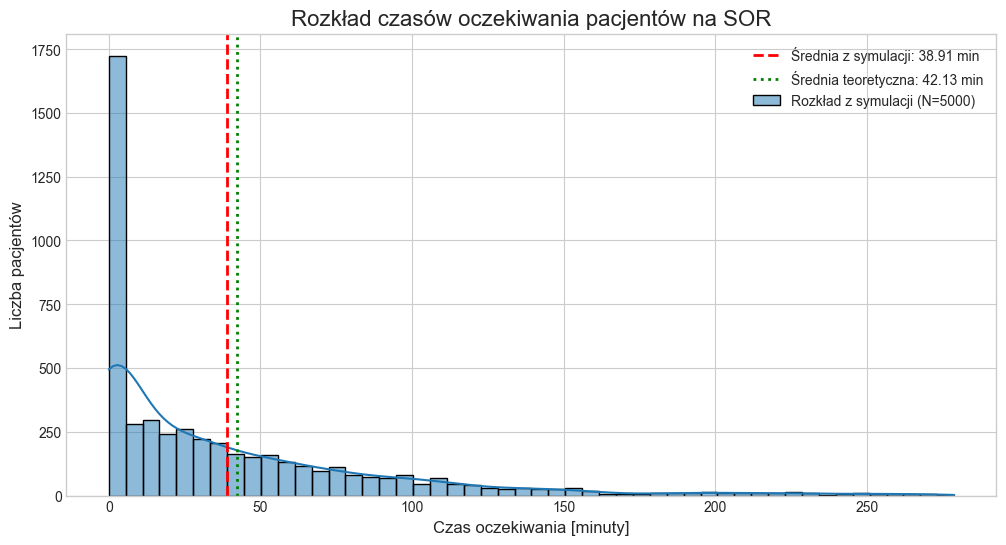

In [664]:
# Wykres rozkładu czasów oczekiwania
if 'sim_results' in locals() and sim_results:
    wait_times_minutes = [t * 60 for t in sim_results['all_wait_times']]

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 6))

    # Histogram
    sns.histplot(wait_times_minutes, bins=50, kde=True, ax=ax,
                 label=f"Rozkład z symulacji (N={len(wait_times_minutes)})")
    
    # Linie dla wartości średnich
    mean_sim_min = sim_results['mean_wait_time'] * 60
    mean_th_min = theoretical_vals['Wq'] * 60
    
    ax.axvline(mean_sim_min, color='red', linestyle='--', linewidth=2,
               label=f'Średnia z symulacji: {mean_sim_min:.2f} min')
    ax.axvline(mean_th_min, color='green', linestyle=':', linewidth=2,
               label=f'Średnia teoretyczna: {mean_th_min:.2f} min')

    ax.set_title('Rozkład czasów oczekiwania pacjentów na SOR', fontsize=16)
    ax.set_xlabel('Czas oczekiwania [minuty]', fontsize=12)
    ax.set_ylabel('Liczba pacjentów', fontsize=12)
    ax.legend()
    plt.show()

### 6. Analiza regresji wielorakiej

                            OLS Regression Results                            
Dep. Variable:              wait_time   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                 1.100e+04
Date:                Thu, 26 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:43:31   Log-Likelihood:                 2380.3
No. Observations:                5000   AIC:                            -4753.
Df Residuals:                    4996   BIC:                            -4727.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              0.1035      0.003     29.

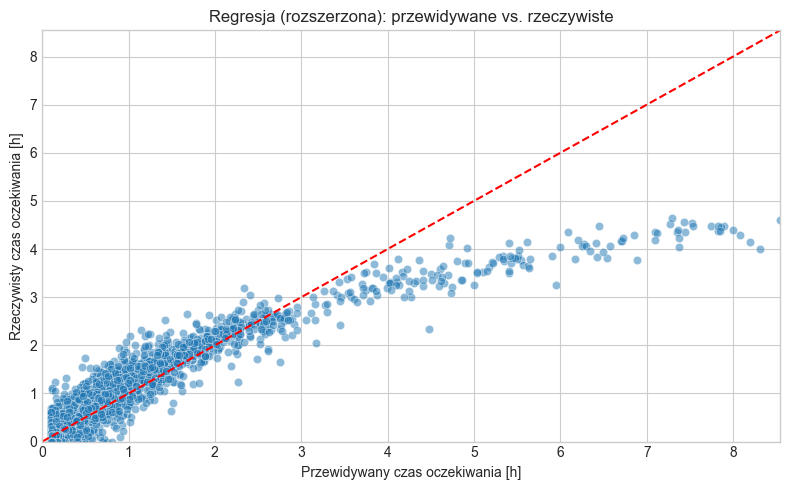

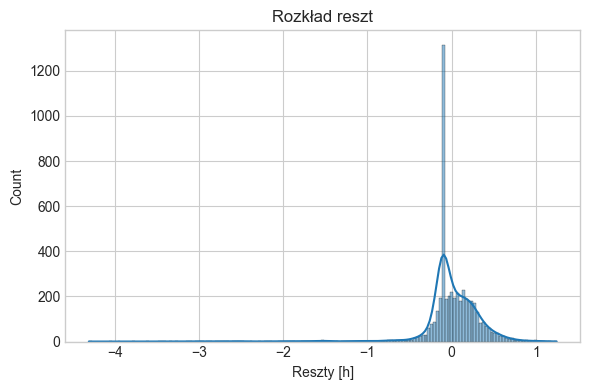

In [665]:
# -------- Regresja wieloraka z dodatkowymi cechami  --------
import numpy as np
import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "wait_time":      sim_results["all_wait_times"],
    "interarrival":   simulator.generated_interarrival_times[:len(sim_results["all_wait_times"])],
    "treatment_time": simulator.generated_treatment_times[:len(sim_results["all_wait_times"])]
})

df["arrival_rate"]  = 1 / df["interarrival"]                
df["lag_wait_time"] = df["wait_time"].shift(1).fillna(0)     

y = np.log1p(df["wait_time"])        

X = df[["arrival_rate", "treatment_time", "lag_wait_time"]]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

#Predykcje 
y_log_pred = model.predict(X)
y_pred     = np.expm1(y_log_pred)    # odwrotność log1p

residuals  = df["wait_time"] - y_pred

# -------- Wykres 1: Predykcja vs. Rzeczywiste --------
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred, y=df["wait_time"], alpha=0.5)
lims = [0, max(df["wait_time"].max(), y_pred.max())]
plt.plot(lims, lims, "--", color="red")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Przewidywany czas oczekiwania [h]")
plt.ylabel("Rzeczywisty czas oczekiwania [h]")
plt.title("Regresja (rozszerzona): przewidywane vs. rzeczywiste")
plt.grid(True); plt.tight_layout()
plt.show()

# -------- Wykres 2: Rozkład reszt --------
plt.figure(figsize=(6, 4))
sns.histplot(residuals, kde=True)
plt.xlabel("Reszty [h]")
plt.title("Rozkład reszt")
plt.tight_layout()
plt.show()